In [1]:
import os, time
from pathlib import Path
import torch
import psutil
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Markdown

%matplotlib inline

display(Markdown("## Part 0 — Setup"))
display(Markdown("_Imports, helpers, RAM tracker, and the model ID. Nothing is downloaded or loaded yet._"))

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10

CATEGORY_COLORS = {
    "weights":          "#d62728",
    "tokenizer":        "#2ca02c",
    "model-config":     "#1f77b4",
    "metadata/license": "#9467bd",
    "other":            "#7f7f7f",
}

PROC = psutil.Process(os.getpid())
def ram_mb(): return PROC.memory_info().rss / (1024 ** 2)

def fmt_size(b):
    if b < 1024:        return f"{b} B"
    if b < 1024**2:     return f"{b/1024:.2f} KB"
    if b < 1024**3:     return f"{b/1024**2:.2f} MB"
    return f"{b/1024**3:.2f} GB"

STAGE_LOG = []

class Stage:
    """Reusable timing + RAM tracker. Use in every level."""
    def __init__(self, name, reads=""):
        self.name, self.reads = name, reads
    def __enter__(self):
        print(f"▶ {self.name}")
        if self.reads: print(f"  reads: {self.reads}")
        self.ram_start = ram_mb()
        self.t_start = time.time()
        return self
    def __exit__(self, *a):
        dt = time.time() - self.t_start
        ram_end = ram_mb()
        delta = ram_end - self.ram_start
        STAGE_LOG.append({
            "stage":         self.name,
            "reads":         self.reads,
            "ram_before_MB": round(self.ram_start, 1),
            "ram_after_MB":  round(ram_end, 1),
            "ram_delta_MB":  round(delta, 1),
            "time_s":        round(dt, 2),
        })
        print(f"  ✓ {dt:.2f}s   ΔRAM +{delta:.1f} MB   total {ram_end:.1f} MB\n")

MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@                PART 00: SETUP COMPLETE                   @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("========== ENVIRONMENT ==========")
print("model id   :", MODEL_ID)
print("torch ver  :", torch.__version__)
print("cuda avail :", torch.cuda.is_available())
print("baseline RAM (notebook only) :", f"{ram_mb():.1f} MB")
print("=================================")

## Part 0 — Setup

_Imports, helpers, RAM tracker, and the model ID. Nothing is downloaded or loaded yet._

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@                PART 00: SETUP COMPLETE                   @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
========== ENVIRONMENT ==========
model id   : meta-llama/Llama-3.2-1B-Instruct
torch ver  : 2.12.0+cpu
cuda avail : False
baseline RAM (notebook only) : 307.0 MB


## Part 1 — Download stage

_Where do files land on disk? What is fetched and in what order?_

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@               PART 01: DOWNLOAD STAGE                    @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@


**Cache before:** hit=`True`, size=`4.61 GB`

========== STEP 1: CACHE CHECK ==========
cache hit : True
cached size : 4.61 GB

========== STEP 2: SNAPSHOT DOWNLOAD ==========
▶ snapshot_download
  reads: huggingface hub


...

  ✓ 0.14s   ΔRAM +2.0 MB   total 320.8 MB

local path : /home/ubuntu/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6



**Cache layout**
- root: `/home/ubuntu/.cache/huggingface/hub`
- snapshot: `/home/ubuntu/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6`
- relative: `models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6`


**Files on disk (small → large = fetch order)**

,filename,category,size
#,,,
1,generation_config.json,model-config,189 B
2,special_tokens_map.json,tokenizer,296 B
3,config.json,model-config,877 B
4,.gitattributes,other,1.48 KB
5,USE_POLICY.md,metadata/license,5.88 KB
6,LICENSE.txt,metadata/license,7.53 KB
7,README.md,metadata/license,40.76 KB
8,tokenizer_config.json,tokenizer,53.25 KB
9,tokenizer.json,tokenizer,8.66 MB



========== STEP 3: FILES ON DISK ==========
file count : 10
total size : 2.31 GB
  model-config              189 B  generation_config.json
  tokenizer                 296 B  special_tokens_map.json
  model-config              877 B  config.json
  other                   1.48 KB  .gitattributes
  metadata/license        5.88 KB  USE_POLICY.md
  metadata/license        7.53 KB  LICENSE.txt
  metadata/license       40.76 KB  README.md
  tokenizer              53.25 KB  tokenizer_config.json
  tokenizer               8.66 MB  tokenizer.json
  weights                 2.30 GB  model.safetensors


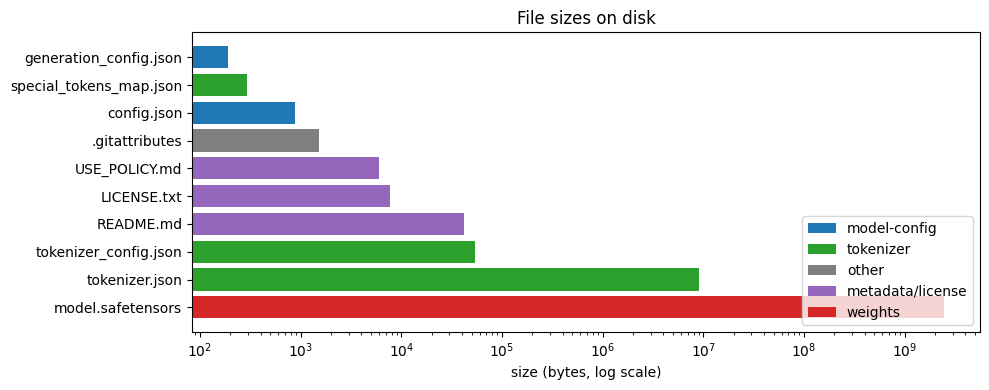


**Summary** — files: `10`, total: `2.31 GB`, fresh: `False`


In [2]:
display(Markdown("## Part 1 — Download stage"))
display(Markdown("_Where do files land on disk? What is fetched and in what order?_"))

from huggingface_hub import snapshot_download, scan_cache_dir

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@               PART 01: DOWNLOAD STAGE                    @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")

def cache_info(model_id):
    try:
        for r in scan_cache_dir().repos:
            if r.repo_id == model_id:
                return True, r.size_on_disk
    except Exception: pass
    return False, 0

cached_before, size_before = cache_info(MODEL_ID)
display(Markdown(f"**Cache before:** hit=`{cached_before}`" +
                 (f", size=`{fmt_size(size_before)}`" if cached_before else "")))

print("========== STEP 1: CACHE CHECK ==========")
print("cache hit :", cached_before)
if cached_before:
    print("cached size :", fmt_size(size_before))
print("=========================================")

print()
print("========== STEP 2: SNAPSHOT DOWNLOAD ==========")
with Stage("snapshot_download", reads="huggingface hub"):
    local_path = snapshot_download(repo_id=MODEL_ID)
print("local path :", local_path)
print("===============================================")

hf_root = Path(os.path.expanduser("~/.cache/huggingface/hub"))
display(Markdown(f"""
**Cache layout**
- root: `{hf_root}`
- snapshot: `{local_path}`
- relative: `{Path(local_path).relative_to(hf_root)}`
"""))

def categorize(name):
    n = name.lower()
    if n.endswith((".safetensors", ".bin")):                return "weights"
    if n in ("config.json", "generation_config.json"):      return "model-config"
    if "tokenizer" in n or n == "special_tokens_map.json":  return "tokenizer"
    if n.endswith((".md", ".txt")):                         return "metadata/license"
    return "other"

rows = []
for f in os.listdir(local_path):
    full = os.path.join(local_path, f)
    if os.path.isfile(full) or os.path.islink(full):
        s = os.path.getsize(full)
        rows.append({"filename": f, "category": categorize(f),
                     "size_bytes": s, "size": fmt_size(s)})

df_files = pd.DataFrame(rows).sort_values("size_bytes").reset_index(drop=True)
df_files.index = range(1, len(df_files) + 1)
df_files.index.name = "#"

display(Markdown("**Files on disk (small → large = fetch order)**"))
display(df_files[["filename", "category", "size"]])

print()
print("========== STEP 3: FILES ON DISK ==========")
print(f"file count : {len(df_files)}")
print(f"total size : {fmt_size(df_files['size_bytes'].sum())}")
for _, row in df_files.iterrows():
    print(f"  {row['category']:18s} {row['size']:>12s}  {row['filename']}")
print("===========================================")

# horizontal bar — file sizes (log scale)
fig, ax = plt.subplots(figsize=(10, max(3, len(df_files) * 0.4)))
ax.barh(df_files["filename"], df_files["size_bytes"],
        color=[CATEGORY_COLORS[c] for c in df_files["category"]])
ax.set_xscale("log")
ax.set_xlabel("size (bytes, log scale)")
ax.set_title("File sizes on disk")
ax.invert_yaxis()
cats_present = df_files["category"].unique()
ax.legend(handles=[Patch(facecolor=CATEGORY_COLORS[c], label=c) for c in cats_present],
          loc="lower right")
plt.tight_layout(); plt.show()

# # pie — disk usage by category
# cat_sizes = df_files.groupby("category")["size_bytes"].sum().sort_values(ascending=False)
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.pie(cat_sizes.values, labels=cat_sizes.index,
#        colors=[CATEGORY_COLORS[c] for c in cat_sizes.index],
#        autopct=lambda p: f"{p:.1f}%\n({fmt_size(p * cat_sizes.sum() / 100)})",
#        startangle=90)
# ax.set_title("Disk usage by category"); plt.tight_layout(); plt.show()

total = df_files["size_bytes"].sum()
display(Markdown(f"""
**Summary** — files: `{len(df_files)}`, total: `{fmt_size(total)}`, fresh: `{not cached_before}`
"""))

## Part 2 — Load into RAM stage

_Disk → RAM. What is read, in what order, how much memory is consumed?_

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@              PART 02: LOAD INTO RAM STAGE                @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@


**Baseline RAM (before model load):** `411.7 MB`

========== STEP 1: BASELINE RAM ==========
RAM before any load : 411.7 MB

========== STEP 2: LOAD TOKENIZER ==========
reads : tokenizer.json, tokenizer_config.json, special_tokens_map.json
▶ load tokenizer
  reads: tokenizer.json, tokenizer_config.json, special_tokens_map.json


...

  ✓ 2.16s   ΔRAM +229.7 MB   total 641.4 MB

tokenizer class : TokenizersBackend
vocab size      : 128000

========== STEP 3: LOAD MODEL CONFIG ==========
reads : config.json
▶ load model config
  reads: config.json
  ✓ 0.02s   ΔRAM +0.0 MB   total 641.4 MB

config class : LlamaConfig
architecture : LlamaForCausalLM

========== STEP 4: LOAD MODEL WEIGHTS ==========
reads : *.safetensors
▶ load model weights
  reads: *.safetensors


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  ✓ 2.92s   ΔRAM +2368.3 MB   total 3009.8 MB

model class :  LlamaForCausalLM
model dtype :  torch.float16
model device:  cpu


**Step-by-step load log**

,stage,reads,ram_before_MB,ram_after_MB,ram_delta_MB,time_s
0,load tokenizer,"tokenizer.json, tokenizer_config.json, special...",411.7,641.4,229.7,2.16
1,load model config,config.json,641.4,641.4,0.0,0.02
2,load model weights,*.safetensors,641.4,3009.8,2368.3,2.92


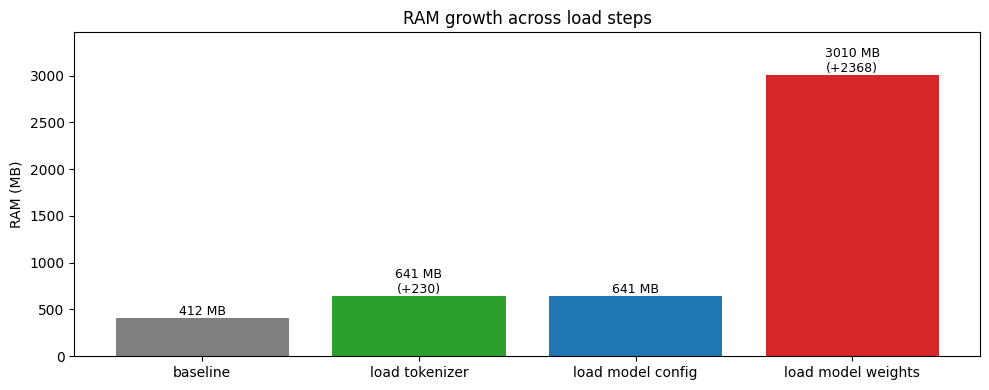

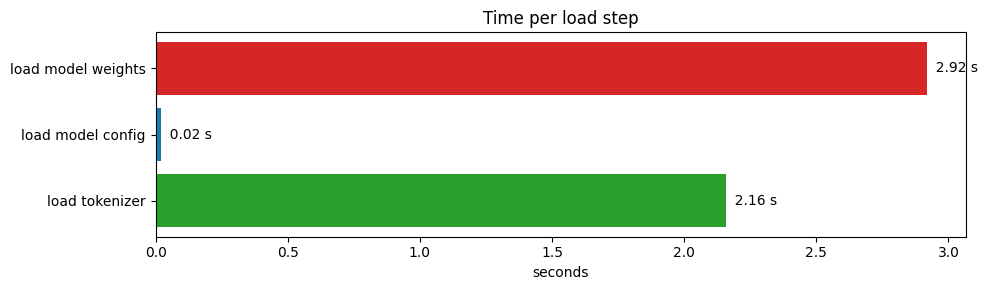


========== STEP 5: MODEL SUMMARY ==========
architecture     : LlamaForCausalLM
hidden size      : 2048
num layers       : 16
vocab size       : 128000
dtype            : torch.float16
device           : cpu
total parameters : 1,235,814,400  (1.236 B)
theoretical size : 2.30 GB
RAM by model     : 2598.5 MB



**Model summary**

| property | value |
|---|---|
| architecture     | `LlamaForCausalLM` |
| hidden size      | `2048` |
| num layers       | `16` |
| vocab size       | `128000` |
| dtype            | `torch.float16` |
| device           | `cpu` |
| total parameters | `1,235,814,400` (1.236 B) |
| theoretical size | `2.30 GB` |
| RAM by model     | `2598.5 MB` |


In [3]:
display(Markdown("## Part 2 — Load into RAM stage"))
display(Markdown("_Disk → RAM. What is read, in what order, how much memory is consumed?_"))

from transformers import AutoTokenizer, AutoConfig, AutoModelForCausalLM

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@              PART 02: LOAD INTO RAM STAGE                @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")

ram_baseline = ram_mb()
display(Markdown(f"**Baseline RAM (before model load):** `{ram_baseline:.1f} MB`"))

print("========== STEP 1: BASELINE RAM ==========")
print(f"RAM before any load : {ram_baseline:.1f} MB")
print("==========================================")

log_start = len(STAGE_LOG)

print()
print("========== STEP 2: LOAD TOKENIZER ==========")
print("reads : tokenizer.json, tokenizer_config.json, special_tokens_map.json")
with Stage("load tokenizer", reads="tokenizer.json, tokenizer_config.json, special_tokens_map.json"):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print("tokenizer class :", type(tokenizer).__name__)
print("vocab size      :", tokenizer.vocab_size)
print("============================================")

print()
print("========== STEP 3: LOAD MODEL CONFIG ==========")
print("reads : config.json")
with Stage("load model config", reads="config.json"):
    config = AutoConfig.from_pretrained(MODEL_ID)
print("config class :", type(config).__name__)
print("architecture :", config.architectures[0] if config.architectures else "n/a")
print("===============================================")

print()
print("========== STEP 4: LOAD MODEL WEIGHTS ==========")
print("reads : *.safetensors")
with Stage("load model weights", reads="*.safetensors"):
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
    model.eval()
print("model class : ", type(model).__name__)
print("model dtype : ", next(model.parameters()).dtype)
print("model device: ", next(model.parameters()).device)
print("================================================")

df_load = pd.DataFrame(STAGE_LOG[log_start:])
display(Markdown("**Step-by-step load log**"))
display(df_load)

# RAM growth bar
labels  = ["baseline"] + df_load["stage"].tolist()
values  = [ram_baseline] + df_load["ram_after_MB"].tolist()
deltas  = [0] + df_load["ram_delta_MB"].tolist()
colors  = ["#7f7f7f", "#2ca02c", "#1f77b4", "#d62728"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, values, color=colors)
for bar, d in zip(bars, deltas):
    h = bar.get_height()
    txt = f"{h:.0f} MB" + (f"\n(+{d:.0f})" if d > 0 else "")
    ax.text(bar.get_x() + bar.get_width()/2, h, txt, ha="center", va="bottom", fontsize=9)
ax.set_ylabel("RAM (MB)"); ax.set_title("RAM growth across load steps")
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout(); plt.show()

# time per step
fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(df_load["stage"], df_load["time_s"], color=["#2ca02c", "#1f77b4", "#d62728"])
for i, v in enumerate(df_load["time_s"]):
    ax.text(v, i, f"  {v:.2f} s", va="center")
ax.set_xlabel("seconds"); ax.set_title("Time per load step")
plt.tight_layout(); plt.show()

total_params = sum(p.numel() for p in model.parameters())
param_bytes  = sum(p.numel() * p.element_size() for p in model.parameters())

print()
print("========== STEP 5: MODEL SUMMARY ==========")
print(f"architecture     : {config.architectures[0] if config.architectures else 'n/a'}")
print(f"hidden size      : {config.hidden_size}")
print(f"num layers       : {config.num_hidden_layers}")
print(f"vocab size       : {tokenizer.vocab_size}")
print(f"dtype            : {next(model.parameters()).dtype}")
print(f"device           : {next(model.parameters()).device}")
print(f"total parameters : {total_params:,}  ({total_params / 1e9:.3f} B)")
print(f"theoretical size : {fmt_size(param_bytes)}")
print(f"RAM by model     : {(ram_mb() - ram_baseline):.1f} MB")
print("===========================================")

display(Markdown(f"""
**Model summary**

| property | value |
|---|---|
| architecture     | `{config.architectures[0] if config.architectures else 'n/a'}` |
| hidden size      | `{config.hidden_size}` |
| num layers       | `{config.num_hidden_layers}` |
| vocab size       | `{tokenizer.vocab_size}` |
| dtype            | `{next(model.parameters()).dtype}` |
| device           | `{next(model.parameters()).device}` |
| total parameters | `{total_params:,}` ({total_params / 1e9:.3f} B) |
| theoretical size | `{fmt_size(param_bytes)}` |
| RAM by model     | `{(ram_mb() - ram_baseline):.1f} MB` |
"""))

In [5]:
from IPython.display import display, Markdown
import pandas as pd
import torch

# ─────────────────────────────────────────────────────────────
# PART 3 — INFERENCE (Level 1: split model call from decode)
# STEP 1 — LLM (opaque box: text-IDs in → 1 new token ID out)
# ─────────────────────────────────────────────────────────────

display(Markdown("## Part 3 — Inference (Level 1: split model call from decode)"))
display(Markdown("### Step 1 — LLM (opaque)"))
display(Markdown("_The model is still a black box. We only observe what goes in and what comes out. Its true output is a single integer (token ID), not text._"))

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@        PART 03 / STEP 1: LLM (opaque) — Level 1          @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")

# ─── INPUT ────────────────────────────────────────────────────
text = "The capital of France is"
inputs = tokenizer(text, return_tensors="pt")
input_ids      = inputs.input_ids
attention_mask = inputs.attention_mask

print("========== IN ==========")
print("text         :", repr(text))
print("input_ids    :", input_ids.tolist())
print("  shape      :", tuple(input_ids.shape))
print("  dtype      :", input_ids.dtype)
print("  ndim       :", input_ids.ndim)
print("  numel      :", input_ids.numel())
print("========================")
print()

# ─── PROCESS (opaque — only metadata of the {model} bundle) ───
total_params = sum(p.numel() for p in model.parameters())
param_bytes  = sum(p.numel() * p.element_size() for p in model.parameters())
model_dtype  = next(model.parameters()).dtype
model_device = next(model.parameters()).device

print("========== PROCESS (opaque) ==========")
print("step             : model.generate(...)")
print("op               : opaque  (black box — internals open from Level 2 onwards)")
print("static used      : {model}  bundles vocab + ALL learned weights")
print("  architecture   :", type(model).__name__)
print("  total params   : {:,}  ({:.3f} B)".format(total_params, total_params/1e9))
print("  param bytes    :", fmt_size(param_bytes))
print("  dtype          :", model_dtype)
print("  device         :", model_device)
print("note             : we DO NOT look inside. We only call generate() and observe outputs.")
print("======================================")
print()

# ─── run the opaque box ───────────────────────────────────────
with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_new_tokens=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

# extract ONLY the new token (the model's true output at Level 1)
new_token_id_tensor = output_ids[0, -1]              # 0-d tensor
new_token_id_int    = int(new_token_id_tensor.item())  # plain Python int

# ─── OUT ──────────────────────────────────────────────────────
print("========== OUT ==========")
print("new_token_id (tensor) :", new_token_id_tensor)
print("  shape               :", tuple(new_token_id_tensor.shape), " <- empty tuple = scalar (0-d)")
print("  dtype               :", new_token_id_tensor.dtype)
print("  ndim                :", new_token_id_tensor.ndim)
print("new_token_id (int)    :", new_token_id_int)
print("=========================")

# ─── Rich view ────────────────────────────────────────────────
display(Markdown("---"))
display(Markdown("### Rich view — Step 1"))

df_step1 = pd.DataFrame([
    {
        "side":  "IN",
        "name":  "input_ids",
        "value": str(input_ids.tolist()),
        "shape": str(tuple(input_ids.shape)),
        "dtype": str(input_ids.dtype),
        "ndim":  input_ids.ndim,
        "dim":   "2D matrix (batch × seq)",
    },
    {
        "side":  "PROCESS",
        "name":  "model.generate (opaque)",
        "value": f"{type(model).__name__}, params={total_params:,}, dtype={model_dtype}",
        "shape": "—",
        "dtype": "—",
        "ndim":  "—",
        "dim":   "opaque",
    },
    {
        "side":  "OUT",
        "name":  "new_token_id",
        "value": str(new_token_id_int),
        "shape": str(tuple(new_token_id_tensor.shape)),
        "dtype": str(new_token_id_tensor.dtype),
        "ndim":  new_token_id_tensor.ndim,
        "dim":   "scalar (0-D)",
    },
]).set_index("side")
display(df_step1)

## Part 3 — Inference (Level 1: split model call from decode)

### Step 1 — LLM (opaque)

_The model is still a black box. We only observe what goes in and what comes out. Its true output is a single integer (token ID), not text._

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@        PART 03 / STEP 1: LLM (opaque) — Level 1          @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
========== IN ==========
text         : 'The capital of France is'
input_ids    : [[128000, 791, 6864, 315, 9822, 374]]
  shape      : (1, 6)
  dtype      : torch.int64
  ndim       : 2
  numel      : 6

========== PROCESS (opaque) ==========
step             : model.generate(...)
op               : opaque  (black box — internals open from Level 2 onwards)
static used      : {model}  bundles vocab + ALL learned weights
  architecture   : LlamaForCausalLM
  total params   : 1,235,814,400  (1.236 B)
  param bytes    : 2.30 GB
  dtype          : torch.float16
  device         : cpu
note             : we DO NOT look inside. We only call generate() and observe outputs.

========== OUT ==========
new_token_id (tensor) : tensor(12366)
  shape               : ()  <- empty tuple = scalar (0-d)
  dtype              

---

### Rich view — Step 1

,name,value,shape,dtype,ndim,dim
side,,,,,,
IN,input_ids,"[[128000, 791, 6864, 315, 9822, 374]]","(1, 6)",torch.int64,2,2D matrix (batch × seq)
PROCESS,model.generate (opaque),"LlamaForCausalLM, params=1,235,814,400, dtype=...",—,—,—,opaque
OUT,new_token_id,12366,(),torch.int64,0,scalar (0-D)


In [6]:
from IPython.display import display, Markdown
import pandas as pd

# ─────────────────────────────────────────────────────────────
# PART 3 — INFERENCE (Level 1)
# STEP 2 — decode (inverse vocab lookup: token ID → text piece)
# This step is NOT opaque. Internals fully shown.
# ─────────────────────────────────────────────────────────────

display(Markdown("### Step 2 — decode (inverse vocab lookup)"))
display(Markdown("_This step is fully transparent. It is a pure table lookup in `{vocab}`. No learned weights, no math — just integer → string._"))

print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
print("@        PART 03 / STEP 2: decode — Level 1                @")
print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")

# ─── IN ──────────────────────────────────────────────────────
# (uses new_token_id_int + new_token_id_tensor from Step 1)
print("========== IN ==========")
print("new_token_id (tensor) :", new_token_id_tensor)
print("  shape               :", tuple(new_token_id_tensor.shape))
print("  dtype               :", new_token_id_tensor.dtype)
print("  ndim                :", new_token_id_tensor.ndim)
print("new_token_id (int)    :", new_token_id_int)
print("========================")
print()

# ─── PROCESS (transparent) ───────────────────────────────────
vocab_size_tok = tokenizer.vocab_size      # base BPE vocab
vocab_size_cfg = config.vocab_size         # incl. added/special tokens (model embedding rows)

print("========== PROCESS (transparent) ==========")
print("step                 : tokenizer.decode(new_token_id)")
print("op                   : inverse vocab lookup  (integer index -> token bytes -> UTF-8 string)")
print("static used          : {vocab}  -- BPE table inside the tokenizer")
print("  tokenizer class    :", type(tokenizer).__name__)
print("  vocab_size (tok)   :", vocab_size_tok,  "  <- base BPE entries")
print("  vocab_size (cfg)   :", vocab_size_cfg,  "  <- model embedding rows (incl. special tokens)")
print("  fast tokenizer     :", tokenizer.is_fast)
print()
print("what happens internally:")
print("  1. Take the integer ID.")
print("  2. Find row [ID] in the BPE vocabulary table.")
print("  3. That row holds a byte sequence (UTF-8 bytes, possibly partial char).")
print("  4. Concatenate bytes, decode as UTF-8, return Python str.")
print("note                 : NO learned weights involved. NO matrix multiplication.")
print("                       Pure deterministic table lookup. Reversible.")
print("===========================================")
print()

# show the actual token string + raw vocab entry
token_str_raw = tokenizer.convert_ids_to_tokens(new_token_id_int)  # raw BPE token (may show 'Ġ' prefix)
text_piece    = tokenizer.decode([new_token_id_int])               # cleaned UTF-8 string

print("========== INTERNAL VOCAB ROW (for inspection) ==========")
print("raw BPE token        :", repr(token_str_raw),
      "  <- 'Ġ' means leading space in GPT-style BPE")
print("decoded text piece   :", repr(text_piece))
print("=========================================================")
print()

# ─── OUT ──────────────────────────────────────────────────────
print("========== OUT ==========")
print("text_piece           :", repr(text_piece))
print("  type               :", type(text_piece).__name__)
print("  len (chars)        :", len(text_piece))
print("=========================")

# ─── Rich view ───────────────────────────────────────────────
display(Markdown("---"))
display(Markdown("### Rich view — Step 2"))

df_step2 = pd.DataFrame([
    {
        "side":  "IN",
        "name":  "new_token_id",
        "value": str(new_token_id_int),
        "shape": str(tuple(new_token_id_tensor.shape)),
        "dtype": str(new_token_id_tensor.dtype),
        "ndim":  new_token_id_tensor.ndim,
        "dim":   "scalar (0-D)",
    },
    {
        "side":  "PROCESS",
        "name":  "tokenizer.decode (inverse vocab lookup)",
        "value": f"{type(tokenizer).__name__}, vocab_size={vocab_size_tok}",
        "shape": "—",
        "dtype": "—",
        "ndim":  "—",
        "dim":   "lookup (no math)",
    },
    {
        "side":  "OUT",
        "name":  "text_piece",
        "value": repr(text_piece),
        "shape": "—",
        "dtype": "str",
        "ndim":  "—",
        "dim":   "string",
    },
]).set_index("side")
display(df_step2)

# ─── Final end-to-end summary (Level 1 pipeline: 2 steps) ────
display(Markdown("---"))
display(Markdown("### Level 1 pipeline — 2 steps"))

df_pipeline = pd.DataFrame([
    {
        "step":           "LLM",
        "op":             "opaque",
        "in":             f"input_ids {tuple(input_ids.shape)} {input_ids.dtype}",
        "static":         "{model}  (vocab + all learned weights)",
        "out":            f"new_token_id  scalar  {new_token_id_tensor.dtype}",
        "dim_out":        "scalar",
    },
    {
        "step":           "decode",
        "op":             "inverse vocab lookup",
        "in":             f"new_token_id  scalar  {new_token_id_tensor.dtype}",
        "static":         "{vocab}  (BPE table)",
        "out":            f"text_piece  {repr(text_piece)}",
        "dim_out":        "string",
    },
])
df_pipeline.index = range(1, len(df_pipeline) + 1)
df_pipeline.index.name = "#"
display(df_pipeline)

### Step 2 — decode (inverse vocab lookup)

_This step is fully transparent. It is a pure table lookup in `{vocab}`. No learned weights, no math — just integer → string._

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@        PART 03 / STEP 2: decode — Level 1                @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
========== IN ==========
new_token_id (tensor) : tensor(12366)
  shape               : ()
  dtype               : torch.int64
  ndim                : 0
new_token_id (int)    : 12366

========== PROCESS (transparent) ==========
step                 : tokenizer.decode(new_token_id)
op                   : inverse vocab lookup  (integer index -> token bytes -> UTF-8 string)
static used          : {vocab}  -- BPE table inside the tokenizer
  tokenizer class    : TokenizersBackend
  vocab_size (tok)   : 128000   <- base BPE entries
  vocab_size (cfg)   : 128256   <- model embedding rows (incl. special tokens)
  fast tokenizer     : True

what happens internally:
  1. Take the integer ID.
  2. Find row [ID] in the BPE vocabulary table.
  3. That row holds a byte sequence (UTF-8 bytes, possibly partial char).
  4.

---

### Rich view — Step 2

,name,value,shape,dtype,ndim,dim
side,,,,,,
IN,new_token_id,12366,(),torch.int64,0,scalar (0-D)
PROCESS,tokenizer.decode (inverse vocab lookup),"TokenizersBackend, vocab_size=128000",—,—,—,lookup (no math)
OUT,text_piece,' Paris',—,str,—,string


---

### Level 1 pipeline — 2 steps

,step,op,in,static,out,dim_out
#,,,,,,
1,LLM,opaque,"input_ids (1, 6) torch.int64",{model} (vocab + all learned weights),new_token_id scalar torch.int64,scalar
2,decode,inverse vocab lookup,new_token_id scalar torch.int64,{vocab} (BPE table),text_piece ' Paris',string
